# Identification of Railway Track Events
Kooros Moabber Lule˚a University, Lule˚a, Sweden and Volvo Cars Corporation, Gothenburg, Sweden


## Introduction
Switches in connection tracks are an essential part of rail way system which are more under stress therefore condition monitoring of them to improve efficiency, increase safety and optimize cost is a must. 

An approach to this monitoring is to measure the acceleration caused by vehicle-track interaction. Any local interruptions in the wheel-rail contact appears in the data as transient impact events.

In this report, these transient events are investigated by using an experimental setup of a railway switch equipped with track-side acceleration sensors in a test track. Figure 1 illustrates the setup with vehicle-track (with front and rear sensors) and local interruptions.

<figure style="text-align: center;">
<img src="SystemSetup.png" width="500">
<name: system-diagram>
<figcaption><b>Figure 1:</b> System Setup</figcaption>
</figure>


## Method
The methodology begins with installing the necessary tools such as python and necessary packages. For this report JupyterLab and Jupyter Notebook via Anaconda were used. Several packages including numpy, panda, matplotlib, ... have been installed. 

In the first section, measured data files, which includes three files, each containing extracted features from 1D acceleration sensor signals which are precomputed, are read to extract features that show abnormalities. All data files has been concatenated in a single dataset in a proper way to save features. The final dataset has been manipulated to remove unnecessary data, normalize data and convert event into binary. The final dataset has been visualize by scatter plot to inspect events effect on features visually.

In the second part, a binary classification task was performed using a Support Vector Machine (SVM) model. The dataset consists of several statistical and frequency features extracted from signals, including mean, standard deviation, skewness, kurtosis, RMS and spectral characteristics (Energy, Centroid, bandwidth and flatness). These features were used as input variables, while the 'event' column served as the binary target label indicating normal or abnormal conditions. 

The model performance was evaluated using two approaches: 
- An 80/20 train-test split
- K-fold cross-validation (with k = 5).

In the first approach, 80% of the dataset was used to train the model and the remaining 20% was used for testing. In the second approach, the dataset was divided into five folds and the model was trained and validated iteratively across different subsets to assess performance consistency and generalization capability. Accuracy, consistency of results and generalization ability have been discussed for both method. 

And finally in the last part, feature selection algorithms are evaluated. The benefits of this investigation are:
- Identifying and retaining the most relevant features and not all of them without sacrificing accuracy and consistency.
- Improving model performance by reducing noise and dimensions

There are different methods for this investigation:
- Filter methods (e.g., Pearson correlation, chi-square test)
- Wrapper methods (e.g., recursive feature elimination)
- Embedded methods (e.g., LASSO, feature importance in tree-based models)
Some of these methods have been implemented in this report.

## Results and Analysis
For extracting data and analyzing them, first data files was read and combined to investigate about statistical and frequency features and detect normal and abnormal events. 

Let's start by importing the necessary packages:

In [1]:
import numpy as np
import pandas as pd
from IPython.display import HTML, display, Markdown
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import skew
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier

### Data Extraction and Manipulation
Data files which are included three files, each containing extracted features from 1D acceleration sensor signals are read as below.

In [2]:
df1 = pd.read_csv('Trail1_extracted_features_acceleration_m1ai1-1-1.csv')
df2 = pd.read_csv('Trail2_extracted_features_acceleration_m1ai1-2.csv')
df3 = pd.read_csv('Trail3_extracted_features_acceleration_m2ai0-2.csv')

Some of these datasets attributes have been investigated. These files contains precomputed statistical and frequency/spectral features but there some extra data fields that are not relevant in this report that will be removed later. 

In [3]:
print(f"size df1:{df1.shape},size df2:{df2.shape},size df3:{df3.shape}")
print(df1.info())
print(df2.info())
print(df3.info())

size df1:(52, 19),size df2:(49, 19),size df3:(49, 22)
<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean                52 non-null     float64
 1   std                 52 non-null     float64
 2   max                 52 non-null     float64
 3   min                 52 non-null     float64
 4   range               52 non-null     float64
 5   skewness            52 non-null     float64
 6   kurtosis            52 non-null     float64
 7   rms                 52 non-null     float64
 8   crest_factor        52 non-null     float64
 9   variance            52 non-null     float64
 10  zero_crossings      52 non-null     int64  
 11  dominant_freq       52 non-null     float64
 12  spectral_energy     52 non-null     float64
 13  spectral_centroid   52 non-null     float64
 14  spectral_bandwidth  52 non-null     float64
 15  spectral_flatnes

Datasets can briefly be investigated by the following commands to understand the properties/attributes of data. Both type of features, time and real events and their sources in the experimental setup are visible in these files.

In [4]:
df1.head(5)

,mean,std,max,min,range,skewness,kurtosis,rms,crest_factor,variance,zero_crossings,dominant_freq,spectral_energy,spectral_centroid,spectral_bandwidth,spectral_flatness,start_time,event,axle
0,-0.000005,0.001350,0.007542,-0.006189,0.013731,-0.004788,0.472182,0.001350,5.587349,0.000002,5798,475.0,7.037723e-08,1962.160093,2412.052659,0.274188,0.000000,normal,normal
1,-0.000006,0.024360,0.215148,-0.249093,0.464241,-0.036717,26.678484,0.024360,8.831983,0.000593,2809,375.0,2.468464e-05,352.868951,257.055863,0.001911,2.886000,joint X,A1
2,0.000016,0.003036,0.013389,-0.014713,0.028103,-0.058478,0.208181,0.003036,4.409818,0.000009,2598,475.0,3.563915e-07,681.251400,1274.187100,0.066875,3.385977,normal,normal
3,0.000067,0.024002,0.298642,-0.290638,0.589279,0.990779,39.908555,0.024002,12.442279,0.000576,1212,75.0,2.348424e-05,263.747571,322.445494,0.002548,6.119000,squat A,A1
4,-0.000148,0.008061,0.024657,-0.042391,0.067048,-0.331677,1.217695,0.008062,3.058305,0.000065,426,75.0,2.240564e-06,244.161218,566.499799,0.011984,6.618984,normal,normal


In [5]:
df2.head(5)

,mean,std,max,min,range,skewness,kurtosis,rms,crest_factor,variance,zero_crossings,dominant_freq,spectral_energy,spectral_centroid,spectral_bandwidth,spectral_flatness,start_time,event,axle
0,-0.000009,0.001330,0.004781,-0.005247,0.010028,-0.011314,-0.004142,0.001330,3.594038,0.000002,5601,475.0,6.991353e-08,1968.369558,2384.453288,0.277275,0.000000,normal,normal
1,-0.000001,0.024833,0.206107,-0.230497,0.436603,-0.353987,28.583506,0.024833,8.299628,0.000617,2376,400.0,2.548043e-05,390.360615,279.200266,0.002057,2.883000,joint X,A1
2,0.000001,0.003160,0.011216,-0.012437,0.023653,-0.022969,0.026897,0.003160,3.548914,0.000010,2524,475.0,3.956581e-07,664.000810,1209.615780,0.060962,3.382969,normal,normal
3,-0.000058,0.035265,0.388397,-0.440529,0.828926,-0.406542,46.475718,0.035266,11.013502,0.001244,1177,125.0,4.823977e-05,221.236299,241.947753,0.001156,5.866000,squat A,A1
4,0.000085,0.007067,0.026800,-0.023521,0.050321,0.213814,0.325838,0.007067,3.792151,0.000050,346,150.0,1.986305e-06,310.327261,604.510643,0.014122,6.365977,normal,normal


In [6]:
df3.head(5)

,mean,std,max,min,range,skewness,kurtosis,rms,crest_factor,variance,...,spectral_energy,spectral_centroid,spectral_bandwidth,spectral_flatness,start_time,event,axle,cluster,tsne_1,tsne_2
0,-0.000008,0.004723,0.016176,-0.014314,0.030491,0.010634,-0.648214,0.004723,3.425033,0.000022,...,8.894379e-07,330.918484,845.602327,0.024392,0.000000,normal,normal,0,-2.309560,4.035162
1,0.000039,0.038715,0.333258,-0.381299,0.714557,-0.584629,22.577204,0.038715,8.608034,0.001499,...,6.287941e-05,336.810570,261.285656,0.000855,3.499000,joint X,A1,1,0.431487,4.996733
2,-0.000028,0.007291,0.029070,-0.022543,0.051612,0.166879,0.081457,0.007291,3.987234,0.000053,...,2.153696e-06,286.508607,570.706370,0.012855,3.998984,normal,normal,0,-2.074971,4.288394
3,-0.000065,0.035973,0.346182,-0.354601,0.700783,0.031652,26.460765,0.035974,9.623257,0.001294,...,5.517608e-05,211.770122,216.868941,0.000879,6.812000,squat A,A1,1,0.026488,5.283027
4,0.000254,0.014505,0.041721,-0.042592,0.084313,-0.130408,-0.435783,0.014507,2.875974,0.000210,...,8.076040e-06,217.224459,530.742319,0.003934,7.311992,normal,normal,0,-2.132229,5.244460


There are numbers of statistical and frequency features that have been extracted from primary processing of sensors data. Let's look at definition of these features:
- Statistical features:
    - Mean: The average value (sum of all numbers divided by how many numbers there are).
    - Standard Deviation (std): Tells us how much the numbers spread out from the average. Example: If most numbers are close to the mean, std is small. If they are far apart, std is big.
    - Max & Min: The biggest and smallest numbers in the dataset.
    - Range: The difference between the max and min.
    - Skewness: Tells us if the data leans more to one side (not balanced). Example: If most students score low but a few score very high, the data is skewed.
    - Kurtosis: Measures whether the data has sharp peaks or flat areas. Example: sharp peaks mean high kurtosis.
    - Root Mean Square (RMS): A special way of averaging numbers that considers both positive and negative values.
    - Crest Factor: Tells us how sharp or smooth a signal is by comparing the peak value to RMS. Example: A smooth wave has a low crest factor; a sharp peak has a high crest factor.
    - Variance: Another way to measure spread, like standard deviation, but squared. Example: If data points are close together, variance is low; if they are far apart, variance is high.
    - Zero Crossings: How many times a signal crosses the zero line. Example: A fast-changing wave crosses zero more often than a slow one.
- Frequency features:
    - Dominant Frequency: The most common frequency in the signal.
    - Spectral Energy: Tells us how much "power" is in the signal. Example: Louder sounds have more energy.
    - Spectral Centroid: Think of it like the "center of gravity" of the sound. Example: High-pitched sounds have a higher centroid than low-pitched ones, meaning their energy is concentrated more toward the higher frequencies.
    - Spectral Bandwidth: Measures how wide the range of frequencies is. Example: A single beep has low bandwidth; a mix of sounds has high bandwidth.
    - Spectral Flatness: Tells us if a sound is smooth (like a whistle) or noisy (like static). Example: White noise (like TV static) has high spectral flatness; a pure tone has low spectral flatness

In this part these datasets are combined. A time sorted dataset for visualizing later is generated also. 

A back up from event field is generated for future use and 'event' field data has been manipulated to replace all normal events with 0 and all other events with 1. 

There are some data fields that are not necessary in this report that are removed later.

Finally, each numerical field is normalized by min-max method where:
$$
x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$
Therefore all features should be between 0 to 1.

In [7]:
df = pd.concat([df1, df2, df3], ignore_index=True)
dfs=df.sort_values(by='start_time') # Sorted dataset vs time
print(f"size combined dataset:{dfs.shape}")
dfs['event_bk'] = dfs['event']
dfs['event'] = dfs['event'].apply(lambda x: 0 if x == 'normal' else 1)
exclude = ['event','event_bk','start_time', 'axle', 'cluster', 'tsne_1', 'tsne_2']
num_cols = dfs.select_dtypes(include=['float64','int64']).columns.difference(exclude)
dfs[num_cols] = (dfs[num_cols] - dfs[num_cols].min()) / (dfs[num_cols].max() - dfs[num_cols].min())
dfs.head(5)

size combined dataset:(150, 22)


,mean,std,max,min,range,skewness,kurtosis,rms,crest_factor,variance,...,spectral_centroid,spectral_bandwidth,spectral_flatness,start_time,event,axle,cluster,tsne_1,tsne_2,event_bk
0,0.500636,0.004049,0.002282,0.998019,0.002108,0.357544,0.012879,0.004049,0.210791,0.000104,...,0.563868,0.920766,0.595135,0.000,0,normal,NaN,NaN,NaN,normal
52,0.493277,0.003829,0.000524,0.998870,0.000722,0.355916,0.007403,0.003829,0.085039,0.000098,...,0.565844,0.909519,0.601842,0.000,0,normal,NaN,NaN,NaN,normal
101,0.494662,0.041939,0.007778,0.990688,0.008384,0.361391,0.000000,0.041939,0.074377,0.002632,...,0.044561,0.282411,0.052414,0.000,0,normal,0.0,-2.30956,4.035162,normal
53,0.507524,0.267832,0.128666,0.795608,0.160459,0.270441,0.336008,0.267831,0.381900,0.075997,...,0.063484,0.051593,0.003888,2.883,1,A1,NaN,NaN,NaN,joint X
1,0.499171,0.262517,0.134420,0.778827,0.170808,0.349580,0.314110,0.262517,0.415485,0.073124,...,0.051548,0.042569,0.003571,2.886,1,A1,NaN,NaN,NaN,joint X


The statistical features versus time and relevant events ('blue'='no event' and 'red' is 'event') are visualized to find out the event effect on these features:

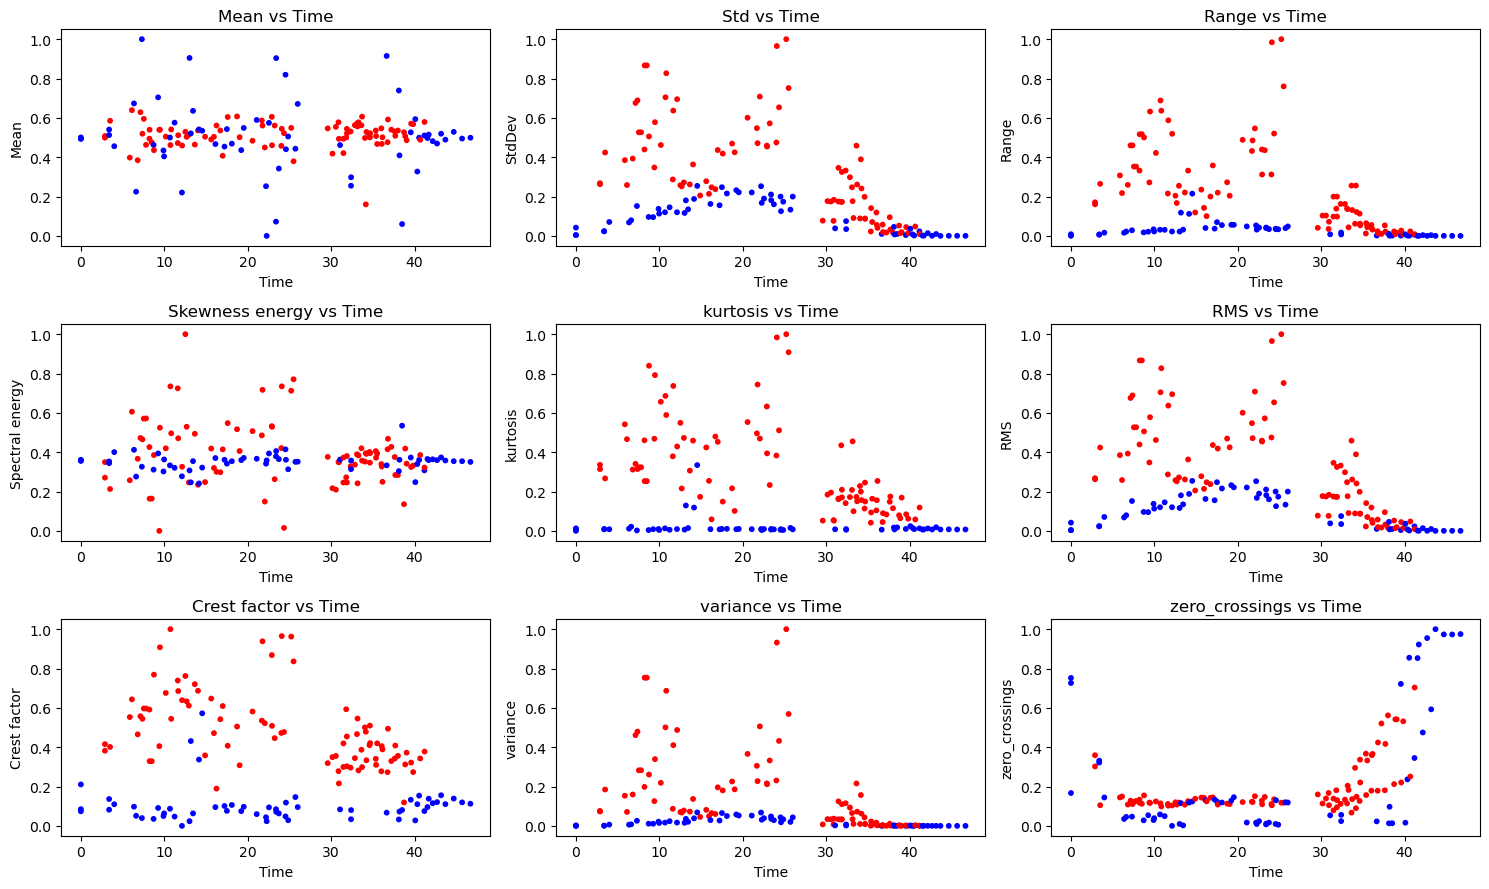

In [8]:
plt.figure(figsize=(15, 9)) # wider figures holder

colors = dfs['event'].apply(lambda x: 'blue' if x == 0 else 'red')

plt.subplot(3, 3, 1)
plt.scatter(dfs['start_time'],dfs['mean'], c=colors, s=10)
plt.title("Mean vs Time")
plt.ylabel("Mean")
plt.xlabel("Time")

plt.subplot(3, 3, 2)
plt.scatter(dfs['start_time'],dfs['std'], c=colors, s=10)
plt.title("Std vs Time")
plt.ylabel("StdDev")
plt.xlabel("Time")

plt.subplot(3, 3, 3)
plt.scatter(dfs['start_time'],dfs['range'], c=colors, s=10)
plt.title("Range vs Time")
plt.ylabel("Range")
plt.xlabel("Time")

plt.subplot(3, 3, 4)
plt.scatter(dfs['start_time'],dfs['skewness'], c=colors, s=10)
plt.title("Skewness energy vs Time")
plt.ylabel("Spectral energy")
plt.xlabel("Time")

plt.subplot(3, 3, 5)
plt.scatter(dfs['start_time'],dfs['kurtosis'], c=colors, s=10)
plt.title("kurtosis vs Time")
plt.ylabel("kurtosis")
plt.xlabel("Time")

plt.subplot(3, 3, 6)
plt.scatter(dfs['start_time'],dfs['rms'], c=colors, s=10)
plt.title("RMS vs Time")
plt.ylabel("RMS")
plt.xlabel("Time")

plt.subplot(3, 3, 7)
plt.scatter(dfs['start_time'],dfs['crest_factor'], c=colors, s=10)
plt.title("Crest factor vs Time")
plt.ylabel("Crest factor")
plt.xlabel("Time")

plt.subplot(3, 3, 8)
plt.scatter(dfs['start_time'],dfs['variance'], c=colors, s=10)
plt.title("variance vs Time")
plt.ylabel("variance")
plt.xlabel("Time")

plt.subplot(3, 3, 9)
plt.scatter(dfs['start_time'],dfs['zero_crossings'], c=colors, s=10)
plt.title("zero_crossings vs Time")
plt.ylabel("zero_crossings")
plt.xlabel("Time")

plt.tight_layout()
plt.show()

These plots show that some of these statistical features like crest factor, kurtosis and range are suitable to distinguish events. 

Looking at frequency features versus time and relevant events ('blue'='no event' and 'red' is 'event') is helping in the similar way to realize the event effect on these frequency features:

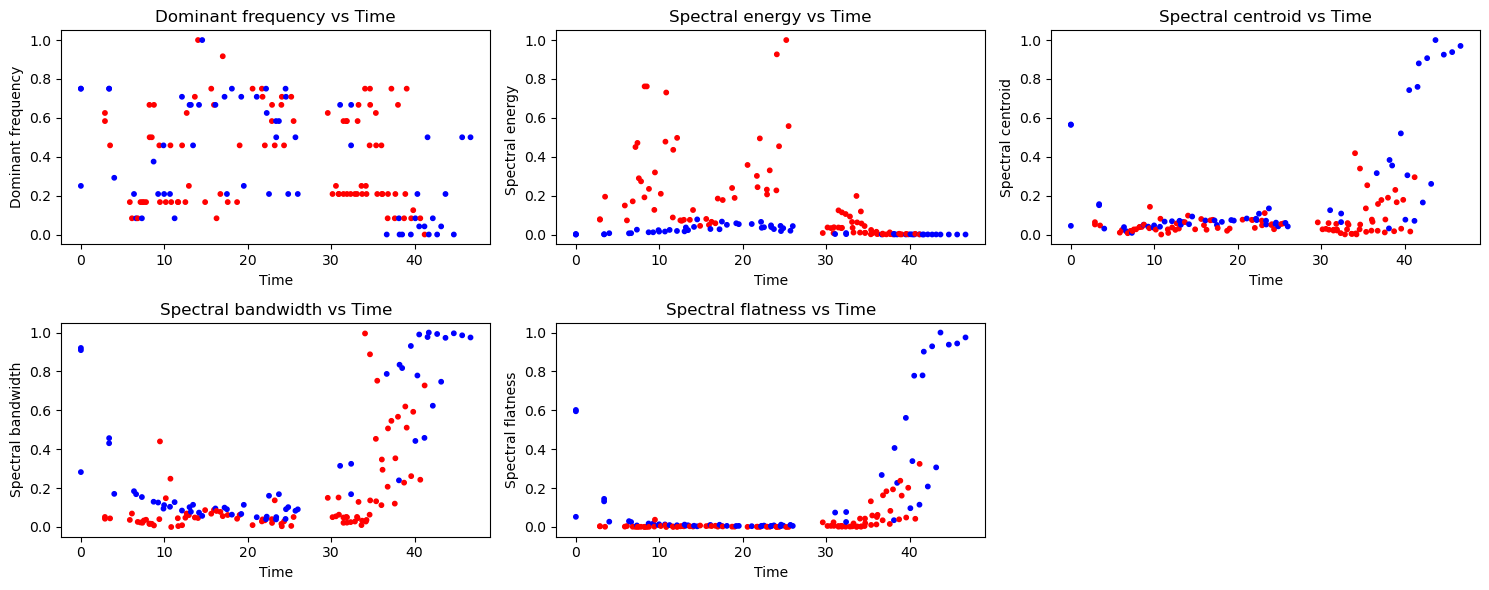

In [9]:
plt.figure(figsize=(15, 6)) # wider figures holder

colors = dfs['event'].apply(lambda x: 'blue' if x == 0 else 'red')

plt.subplot(2, 3, 1)
plt.scatter(dfs['start_time'],dfs['dominant_freq'], c=colors, s=10)
plt.title("Dominant frequency vs Time")
plt.ylabel("Dominant frequency")
plt.xlabel("Time")

plt.subplot(2, 3, 2)
plt.scatter(dfs['start_time'],dfs['spectral_energy'], c=colors, s=10)
plt.title("Spectral energy vs Time")
plt.ylabel("Spectral energy ")
plt.xlabel("Time")

plt.subplot(2, 3, 3)
plt.scatter(dfs['start_time'],dfs['spectral_centroid'], c=colors, s=10)
plt.title("Spectral centroid vs Time")
plt.ylabel("Spectral centroid")
plt.xlabel("Time")

plt.subplot(2, 3, 4)
plt.scatter(dfs['start_time'],dfs['spectral_bandwidth'], c=colors, s=10)
plt.title("Spectral bandwidth vs Time")
plt.ylabel("Spectral bandwidth")
plt.xlabel("Time")

plt.subplot(2, 3, 5)
plt.scatter(dfs['start_time'],dfs['spectral_flatness'], c=colors, s=10)
plt.title("Spectral flatness vs Time")
plt.ylabel("Spectral flatness")
plt.xlabel("Time")

plt.tight_layout()
plt.show()

These plots show that some of these frequency features like spectral energy are suitable to distinguish events.

After time analysis, the columns start_time, axle, cluster, tsne_1 and tsne_2 from combined dataset are removed for making data ready for the binary classification using machine learning in the next section:

In [10]:
dfsn = dfs.drop(['start_time', 'axle', 'cluster', 'tsne_1', 'tsne_2','event_bk'], axis=1)
print(f"Size combined dataset: {dfsn.shape} ")
dfsn.head(5)

Size combined dataset: (150, 17) 


,mean,std,max,min,range,skewness,kurtosis,rms,crest_factor,variance,zero_crossings,dominant_freq,spectral_energy,spectral_centroid,spectral_bandwidth,spectral_flatness,event
0,0.500636,0.004049,0.002282,0.998019,0.002108,0.357544,0.012879,0.004049,0.210791,0.000104,0.752236,0.750000,0.000099,0.563868,0.920766,0.595135,0
52,0.493277,0.003829,0.000524,0.998870,0.000722,0.355916,0.007403,0.003829,0.085039,0.000098,0.726328,0.750000,0.000097,0.565844,0.909519,0.601842,0
101,0.494662,0.041939,0.007778,0.990688,0.008384,0.361391,0.000000,0.041939,0.074377,0.002632,0.167017,0.250000,0.002632,0.044561,0.282411,0.052414,0
53,0.507524,0.267832,0.128666,0.795608,0.160459,0.270441,0.336008,0.267831,0.381900,0.075997,0.302209,0.625000,0.078694,0.063484,0.051593,0.003888,1
1,0.499171,0.262517,0.134420,0.778827,0.170808,0.349580,0.314110,0.262517,0.415485,0.073124,0.359153,0.583333,0.076233,0.051548,0.042569,0.003571,1


### Evaluating Support Vector Machines (SVM) Performance
Evaluating the performance of a machine learning model is an essential step to ensure that the model can generalize well to unseen data. 

There are different machine learning for binary classification such Random Forest, Gradient Boosting, K-Nearest Neighbors (KNN) and Support Vector Machine (SVM). In this report, the performance of a SVM binary classifier, when this model draws the best boundary (line or curve) to separate two groups, is assessed by using two common evaluation methods: 
- 80/20 train-test split
- K-fold cross-validation

In 80/20 train-test split, the dataset is first divided into training and testing subsets, where 80% of the data is used to train the model and the remaining 20% is used to evaluate its predictive performance.

In K-fold cross-validation dataset is randomly partitioned into k equal-sized subsets or "folds". The training and validation process is then repeated k times, where in each iteration, one specific fold is held out for validation (testing) while the remaining k-1 folds are combined to train the model. Consequently, every single data point has the opportunity to be used in the test set exactly once and in the training set k-1 times. This method is applied to provide a robust estimation of model accuracy, stability and generalization ability.

By comparing these two evaluation approaches, it is possible to analyze and compare their accuracy, consistency of results, generalization ability and the reliability of performance.

For both methods, following steps should be done:
- Selection of features (X: input) and binary target (y: output)
- Train and test data split
- Train one of the ML models (here is SVM)
- Evaluate the model by two mentioned methods for:
  - Accuracy: For measuring how much model is correct.
  - Consistency (Standard Deviation of accuracy): For measuring the consistency by 80/20 train-test split and K-fold cross-validation, you mainly look at how much the model performance varies across different runs. One method to measure consistency is to evaluate how much the model produces similar accuracy results when the data split changes. 
  - Generalization ability: This shows how well a trained model performs on new, unseen data rather than only on the data used for training. One method For measuring generalizations ability is to compare the train accuracy versus test accuracy. There are three possible scenarios when test accuracy is compared with trained accuracy:
    - Train accuracy in the same rang of test accuracy: Good generalization
    - Train accuracy >> test accuracy: Over fitting (poor generalization)
    - Train accuracy << test accuracy: Under fitting (poor generalization)

#### 80/20 Train-Test Split
In this section, the mentioned steps are followed. 
##### Selection of features and binary target:
The first step is selection of features and binary target. Binary target is 'event' field where it is either '0' for normal data and '1' if there is any event. 

In [11]:
features = [
'mean','std','max','min','range','skewness','kurtosis','rms',
'crest_factor','variance','zero_crossings','dominant_freq',
'spectral_energy','spectral_centroid','spectral_bandwidth',
'spectral_flatness'] # input features
X = dfsn[features] 
y = dfsn['event'] # Binary target

##### Train and test split and train SVM binary models:
In this part the dataset is split 80% for training and 20% for testing. The model is made by train data and tested by test data. As we mentioned before in the evaluation of consistency, a single split of train and test data does not show consistency therefore we should repeat it multiple times with different random seeds. The test and train accuracies are accumulated to evaluate later.

In [12]:
# Help from Gemini
test_accuracies = [] # Array for test accuracy saving
train_accuracies=[] # Array for test accuracy saving for generalization

for i in range(30): # repeat 30 random splits
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i
    ) # split 80/20 data
    
    model = SVC(kernel='rbf') # SVC non-linear modeling with Radial Basis Function (RBF)
    # model = SVC(kernel='rbf', C=1.0, gamma='scale')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = model.score(X_train, y_train)

    test_accuracies.append(test_acc)
    train_accuracies.append(train_acc)


##### Test Accuracy, Consistency and Generalization
In this part, the accuracy mean and standard deviation show how much model is accurate and consistent. 

In [13]:
# print("Test accuracies:", np.round(test_accuracies,2))
tt_test_mean = np.round(np.mean(test_accuracies),3)
tt_test_std = np.round(np.std(test_accuracies),3)
print("80/20 Test accuracies mean:", tt_test_mean)
print("80/20 Test accuracies std:", tt_test_std )
display(Markdown(f"{tt_test_mean:.3f} test accuracy with {tt_test_std:.3f} standard deviation is enough good for 80/20 train test split method."))

80/20 Test accuracies mean: 0.961
80/20 Test accuracies std: 0.03


0.961 test accuracy with 0.030 standard deviation is enough good for 80/20 train test split method.

For checking the generalization, the trained accuracy shows that how much the model fit to trained data. The expectation is that train accuracy mean should be higher than test accuracy mean and train accuracy stand deviation should be lower than test accuracy standard deviation since the train data are the data that is used for training model. comparison of Train accuracy and test accuracy is a good criterion for Generalization ability that has been explained before.

In [14]:
# print("Train accuracies:", np.round(train_accuracies,2))
tt_train_mean = np.round(np.mean(train_accuracies),3)
tt_train_std = np.round(np.std(train_accuracies),3)
print("80/20 Train accuracies mean:", tt_train_mean)
print("80/20 Train accuracies std:", tt_train_std)
display(Markdown(f"In our case train accuracy mean ({tt_train_mean:0.3f}) and test \
accuracy mean ({tt_test_mean:0.3f}) are almost in the same range \
therefore there is a good generalization."))

80/20 Train accuracies mean: 0.974
80/20 Train accuracies std: 0.007


In our case train accuracy mean (0.974) and test accuracy mean (0.961) are almost in the same range therefore there is a good generalization.

#### K-fold cross-validation
The k-fold (5-fold) cross validation is Performed on the training set to evaluate model stability. 

In [15]:
# Help from Claude
kmodel = SVC(kernel='rbf') # SVC non-linear modeling with Radial Basis Function (RBF)
# kmodel = SVC(kernel='rbf', C=1.0, gamma='scale')

cvn = RepeatedStratifiedKFold(n_splits=5, n_repeats=30, random_state=42)
cv_results = cross_validate(kmodel, X, y, cv=cvn, return_train_score=True)

selected_feature_kf = features
selected_features_kf_no = len(selected_feature_kf)
print(f"K-fold Selected Features [no = {selected_features_kf_no}]:")
print(selected_feature_kf)

test_scores = cv_results['test_score']
train_scores = cv_results['train_score']

#print("Test accuracies:", np.round(test_scores,2))
kf_test_mean = np.round(test_scores.mean(),3)
kf_test_std = np.round(test_scores.std(),3)
print("K-Fold Test accuracies mean:", kf_test_mean)
print("K-Fold Test accuracies std:", kf_test_std )
#print("Train accuracies:", np.round(train_scores,2))
kf_train_mean = np.round(train_scores.mean(),3)
kf_train_std = np.round(train_scores.std(),3)
print("K-Fold Train accuracies mean:", kf_train_mean)
print("K-Fold Train accuracies std:", kf_train_std)
display(Markdown(f"{kf_test_mean:0.3f} test accuracy with {kf_test_std:0.3f} standard deviation \
are really good for K-fold cross validation method. \
For generalization, train accuracy mean ({kf_train_mean:0.3f}) and test accuracy mean ({kf_test_mean:0.3f}) \
are very close that shows very good generalization."))

K-fold Selected Features [no = 16]:
['mean', 'std', 'max', 'min', 'range', 'skewness', 'kurtosis', 'rms', 'crest_factor', 'variance', 'zero_crossings', 'dominant_freq', 'spectral_energy', 'spectral_centroid', 'spectral_bandwidth', 'spectral_flatness']
K-Fold Test accuracies mean: 0.971
K-Fold Test accuracies std: 0.028
K-Fold Train accuracies mean: 0.973
K-Fold Train accuracies std: 0.007


0.971 test accuracy with 0.028 standard deviation are really good for K-fold cross validation method. For generalization, train accuracy mean (0.973) and test accuracy mean (0.971) are very close that shows very good generalization.

### Analysis and Discussions
A table to summarize all techniques has been generated by code to be dynamic:

In [16]:
results_table = pd.DataFrame({
    "Method": [
        "80/20 method", "K-fold method"],
    "Test Accuracy Mean": [tt_test_mean, kf_test_mean],
    "Train Accuracy Mean": [
        tt_train_mean,
        kf_train_mean],
    "Test Accuracy Std": [
        tt_test_std,
        kf_test_std],
    "Train Accuracy Std": [
        tt_train_std,
        kf_train_std]
})
results_table.style.format({
    "Test Mean": "{:.3f}",
    "Train Mean": "{:.3f}",
    "Test Std": "{:.3f}",
    "Train Std": "{:.3f}"
}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'center')])]
).set_properties(**{'text-align': 'center'})

,Method,Test Accuracy Mean,Train Accuracy Mean,Test Accuracy Std,Train Accuracy Std
0,80/20 method,0.961000,0.974000,0.030000,0.007000
1,K-fold method,0.971000,0.973000,0.028000,0.007000


Above table illustrates the 80/20 train-test vs K-fold cross-validation.

Test accuracy mean of 0.961 in the 80/20 evaluating method while the K-fold cross-validation achieved a slightly higher test accuracy mean of 0.971. The small difference between the two approaches confirms that the model generalizes well to unseen data. Furthermore, the low standard deviations in both methods (approximately 0.03 or lower) indicate stable and consistent performance across different data partitions in both method. In addition, the small difference between the two approaches test and train accuracy mean confirms that the model generalizes well to unknown data and suggest that the model does not suffer from significant over/under fitting. 

Overall, K-fold cross-validation provides a slightly more robust and reliable estimate of generalization performance, while the 80/20 split confirms the model strong predictive ability.

### Feature Selection Techniques 
There are different feature selection techniques. These techniques quickly check which features are useful before using a model. Some of these methods/techniques are listed as follow:
- Filter methods: In these methods features are picked based on statistics. There are different techniques:
    - Pearson correlation: Measures how strongly two things are related (correlated). Measuring cross correlation between the output event and input features and selection of those features that most effective on the output are targets in this method.
    - chi-square test: Checks if one feature affects another one. 
- Wrapper methods: In these methods different feature combinations are tried. These methods use a model to test different feature sets and see which work best. Recursive feature elimination is one of the known methods. In this method, model starts with all features, removes the least useful one, checks the model's performance and repeats the process until only the best features remain.
- Embedded methods: In these methods model makes decision the important features. There are different methods:
    - LASSO (Least Absolute Shrinkage and Selection Operator): A method that makes the model automatically ignore unimportant features.
    - Tree-based models: These models can tell us which features are most important by checking how often they are used in decision-making.

#### Pearson Correlation Method
In this method correlations between target variable which is 'event' and features are measured and those one that are more than a specific threshold is selected to make a model.

In this section, event is added to whole features that its cross correlations can be extracted and illustrated in Figure 2.

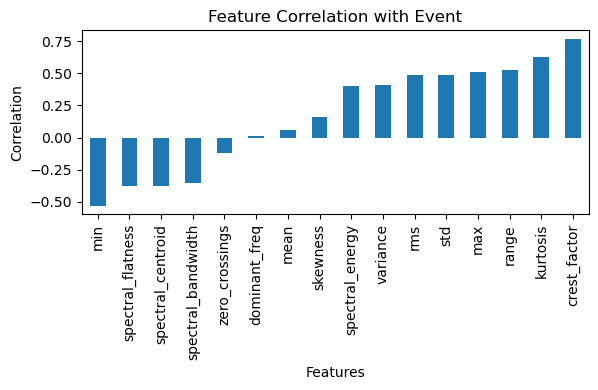

Figure 2: Features correlations with event

In [17]:
cross_features = [
'mean','std','max','min','range','skewness','kurtosis','rms',
'crest_factor','variance','zero_crossings','dominant_freq',
'spectral_energy','spectral_centroid','spectral_bandwidth',
'spectral_flatness','event'] # cross features
dfs_cross_temp= dfs[cross_features]
# Calculate correlation matrix
correlation_matrix = dfs_cross_temp.corr()

# Get correlation of each feature with target
target_correlation = correlation_matrix['event'].drop('event')

# Show correlation values
plt.figure(figsize=(6,4)) # smaller figure helps centering
target_correlation.sort_values().plot(kind='bar')
plt.title("Feature Correlation with Event")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.tight_layout()
plt.show()
display(Markdown("Figure 2: Features correlations with event"))

Above figure shows the linear relationship between statistical/frequency features and event. Value ranges are from -1 to +1 where:
- +1: strong positive relationship
- -1: strong negative relationship
- 0: no linear relationship

Positive values show the positive correlation between that feature and event and the negative one show the negative correlation of that specific feature on event. The level of correlation also demonstrates the level of this dependency. 

Let's put a threshold value and take strong features which have a high correlation with event.

In [18]:
Pearson_threshold = 0.5 # Threshold value

selected_features_Pearson = target_correlation[abs(target_correlation) > Pearson_threshold].index
selected_features_Pearson_no = len(selected_features_Pearson)

print(f"Pearson Selected Features [no = {selected_features_Pearson_no}]:")
print(selected_features_Pearson)

# Create new dataset with selected features
X_selected_Pearson = X[selected_features_Pearson]

Pearson Selected Features [no = 5]:
Index(['max', 'min', 'range', 'kurtosis', 'crest_factor'], dtype='str')


Indeed by changing the threshold, the number of the extracted features is changed. The bigger threshold the less number of selected features. The new selected features by this method is used in k-fold cross-validation:

In [19]:
X_cv_results = cross_validate(kmodel, X_selected_Pearson, y, cv=cvn, return_train_score=True)

X_test_scores = X_cv_results['test_score']
X_train_scores = X_cv_results['train_score']

#print("Test accuracies:", np.round(test_scores,2))
Pearson_test_mean = np.round(X_test_scores.mean(),3)
Pearson_test_std = np.round(X_test_scores.std(),3)
print("Pearson K-Fold Test accuracies mean:", Pearson_test_mean)
print("Pearson K-Fold Test accuracies std:", Pearson_test_std)
#print("Train accuracies:", np.round(train_scores,2))
Pearson_train_mean = np.round(X_train_scores.mean(),3)
Pearson_train_std = np.round(X_train_scores.std(),3)
print("Pearson K-Fold Train accuracies mean:", Pearson_train_mean)
print("Pearson K-Fold Train accuracies std:", Pearson_train_std)

Pearson K-Fold Test accuracies mean: 0.964
Pearson K-Fold Test accuracies std: 0.031
Pearson K-Fold Train accuracies mean: 0.964
Pearson K-Fold Train accuracies std: 0.009


After implementation of other feature selection methods, they are analyzed and discussed together.

#### Chi-square Method
In this method, test was applied as a filter method for feature selection. It evaluates the dependency between each feature and the target variable ('event'). For each feature Chi square is calculate according to the following formula:
$$
\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}
$$
Where:

$\chi^2$ = Chi-square statistic

$O_i$ = observed frequency of class i

$E_i$ = expected frequency of class i if there were no relationship

$k$ = number of categories or classes


Features with higher Chi-square scores were considered more relevant and selected for model training. In this method, all feature should be non-negative that they have already normalized between 0 to 1.

Let's use the SelecKBest and chi2 functions in scikit-learn to selct the 5 most important features.

In [20]:
# Help from Claude
feature_num = 3 # the 5 most important features

chi2_selector = SelectKBest(score_func=chi2, k=feature_num)
X_selected_Chi2 = chi2_selector.fit_transform(X, y)

# Get selected feature names
selected_features_Chi2 = X.columns[chi2_selector.get_support()]
selected_features_Chi2_no = len(selected_features_Chi2)

print(f"Chi2 Selected Features [no = {selected_features_Chi2_no}]:")
print(selected_features_Chi2)

# Create new dataset with selected features
X_selected_Chi2 = X[selected_features_Chi2]
# X_selected_Chi2.info()

Chi2 Selected Features [no = 3]:
Index(['kurtosis', 'crest_factor', 'spectral_flatness'], dtype='str')


The new selected features by this method is used in k-fold cross-validation:

In [21]:
chi2_cv_results = cross_validate(kmodel, X_selected_Chi2, y, cv=cvn, return_train_score=True)

chi2_test_scores = chi2_cv_results['test_score']
chi2_train_scores = chi2_cv_results['train_score']

#print("Test accuracies:", np.round(test_scores,2))
Chi2_test_mean = np.round(chi2_test_scores.mean(),3)
Chi2_test_std = np.round(chi2_test_scores.std(),3)
print("Chi2 K-Fold Test accuracies mean:", Chi2_test_mean)
print("Chi2 K-Fold Test accuracies std:", Chi2_test_std)
#print("Train accuracies:", np.round(train_scores,2))
Chi2_train_mean = np.round(chi2_train_scores.mean(),3)
Chi2_train_std = np.round(chi2_train_scores.std(),3)
print("Chi2 K-Fold Train accuracies mean:", Chi2_train_mean)
print("Chi2 K-Fold Train accuracies std:", Chi2_train_std)

Chi2 K-Fold Test accuracies mean: 0.967
Chi2 K-Fold Test accuracies std: 0.03
Chi2 K-Fold Train accuracies mean: 0.967
Chi2 K-Fold Train accuracies std: 0.008


#### LASSO Method
LASSO (Least Absolute Shrinkage and Selection Operator) was applied as an embedded feature selection method. For this purpose, following optimization problem is solved to minimize the coefficient of features:
$$\min_{\beta_0,\beta} \left( \sum_{i=1}^{n} (y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij})^2 + \alpha \sum_{j=1}^{p} |\beta_j| \right)$$
where:

$y_i$ = target value for observation $i$  

$x_{ij}$ = value of feature $j$ for observation $i$  

$\beta_j$ = coefficient of feature $j$  

$\beta_0$ = intercept of the model  

$p$ = number of features  

$n$ = number of samples  

$\alpha$ = regularization parameter controlling the strength of the penalty

By introducing L1 regularization in the above optimization problem:
$$
\alpha\sum_{j=1}^{p} |\beta_j|
$$
the model automatically shrinks less important feature coefficients to zero. If larger $\alpha$ is selected, many coefficients become zero and more feature selection happens.  

As a result, LASSO simultaneously performs model fitting and feature selection, helping to reduce model complexity and prevent overfitting. It means that Unlike filter methods that evaluate features independently, LASSO performs feature selection during model training. At the end, features with non-zero coefficients were retained for model training. 

In [22]:
# Help from ChatGPT
# Train LASSO Model
lasso_alpha=0.01 # alpha controls regularization strength
lasso = Lasso(alpha=lasso_alpha)
lasso.fit(X, y)

# Select the non-zero coefficient features
# Get coefficients
coefficients = pd.Series(lasso.coef_, index=X.columns)
# print(coefficients)

# Selected features (non-zero)
selected_features_lasso = coefficients[coefficients != 0].index.tolist()
selected_features_lasso_no = len(selected_features_lasso)

print(f"LASSO Selected Features [no = {selected_features_lasso_no}]:")
print(selected_features_lasso)

# Create new dataset with selected features
X_selected_lasso = X[selected_features_lasso]

LASSO Selected Features [no = 4]:
['skewness', 'crest_factor', 'dominant_freq', 'spectral_centroid']


The new selected features by this method is used in k-fold cross-validation:

In [23]:
Lasso_cv_results = cross_validate(kmodel, X_selected_lasso, y, cv=cvn, return_train_score=True)

Lasso_test_scores = Lasso_cv_results['test_score']
Lasso_train_scores = Lasso_cv_results['train_score']

#print("Test accuracies:", np.round(test_scores,2))
Lasso_test_mean = np.round(Lasso_test_scores.mean(),3)
Lasso_test_std = np.round(Lasso_test_scores.std(),3)
print("LASSO K-Fold Test accuracies mean:", Lasso_test_mean)
print("LASSO K-Fold Test accuracies std:", Lasso_test_std )
#print("Train accuracies:", np.round(train_scores,2))
Lasso_train_mean = np.round(Lasso_train_scores.mean(),3)
Lasso_train_std = np.round(Lasso_train_scores.std(),3)
print("LASSO K-Fold Train accuracies mean:", Lasso_train_mean)
print("LASSO K-Fold Train accuracies std:", Lasso_train_std)

LASSO K-Fold Test accuracies mean: 0.97
LASSO K-Fold Test accuracies std: 0.029
LASSO K-Fold Train accuracies mean: 0.973
LASSO K-Fold Train accuracies std: 0.007


#### Tree-based models (Random Forests) Method
A tree-based feature selection method was applied using Decision Tree and Random Forest models. Random Forest is generally preferred because it provides more stable and robust estimates of feature importance by combining multiple decision trees. 

Tree-based models estimate feature importance based on how much each feature contributes to reducing prediction error during the splitting process in the trees. Features with higher importance scores were selected (importance above a predefined threshold), while less informative features were removed. This approach helps identify the most relevant predictors and can improve model performance by reducing noise and overfitting. In the following implementation, the parameter n_estimators defines the number of decision trees in the Random Forest ensemble. Increasing the number of trees improves model stability and reduces variance. 

In [24]:
# Help from Gemini
# Train random forest model
# n_estimators = number of decision trees in the Random Forest.
# 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Find importance of features
importances = pd.Series(rf.feature_importances_, index=X.columns)
# print(importances .sort_values(ascending=False))

# Get selected feature names
RF_threshold = 0.07
selected_features_RF = importances[importances > RF_threshold].index.tolist()
selected_features_RF_no=len(selected_features_RF)

print(f"Random forest Selected Features [no = {selected_features_RF_no}]:")
print(selected_features_RF)

# Create new dataset with selected features
X_selected_RF = X[selected_features_RF]

Random forest Selected Features [no = 4]:
['max', 'min', 'kurtosis', 'crest_factor']


The new selected features by this method is used in k-fold cross-validation:

In [25]:
RF_cv_results = cross_validate(kmodel, X_selected_RF, y, cv=cvn, return_train_score=True)

RF_test_scores = RF_cv_results['test_score']
RF_train_scores = RF_cv_results['train_score']

#print("Test accuracies:", np.round(test_scores,2))
RF_test_mean = np.round(RF_test_scores.mean(),3)
RF_test_std = np.round(RF_test_scores.std(),3)
print("Random Forests K-Fold Test accuracies mean:", RF_test_mean)
print("Random Forests K-Fold Test accuracies std:", RF_test_std)
#print("Train accuracies:", np.round(train_scores,2))
RF_train_mean = np.round(RF_train_scores.mean(),3)
RF_train_std = np.round(RF_train_scores.std(),3)
print("Random Forests K-Fold Train accuracies mean:", RF_train_mean)
print("Random Forests K-Fold Train accuracies std:", RF_train_std)

Random Forests K-Fold Test accuracies mean: 0.964
Random Forests K-Fold Test accuracies std: 0.031
Random Forests K-Fold Train accuracies mean: 0.966
Random Forests K-Fold Train accuracies std: 0.008


### Analysis and Discussions
In the following table the selected features by all these methods are shown:

In [26]:
feature_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Overall K-fold": [1 if f in X.columns else 0 for f in X.columns],
    "Pearson K-fold": [1 if f in selected_features_Pearson else 0 for f in X.columns],
    "Chi2 K-fold": [1 if f in selected_features_Chi2 else 0 for f in X.columns],
    "LASSO K-fold": [1 if f in selected_features_lasso else 0 for f in X.columns],
    "RandomForest K-fold": [1 if f in selected_features_RF else 0 for f in X.columns]
})

# Create Score column (sum of selected methods)
feature_comparison["Total Score"] = (
    feature_comparison["Pearson K-fold"] +
    feature_comparison["Chi2 K-fold"] +
    feature_comparison["LASSO K-fold"] +
    feature_comparison["RandomForest K-fold"]
)

feature_comparison

,Feature,Overall K-fold,Pearson K-fold,Chi2 K-fold,LASSO K-fold,RandomForest K-fold,Total Score
0,mean,1,0,0,0,0,0
1,std,1,0,0,0,0,0
2,max,1,1,0,0,1,2
3,min,1,1,0,0,1,2
4,range,1,1,0,0,0,1
5,skewness,1,0,0,1,0,1
6,kurtosis,1,1,1,0,1,3
7,rms,1,0,0,0,0,0
8,crest_factor,1,1,1,1,1,4
9,variance,1,0,0,0,0,0


In this table, the feature crest_factor achieved the highest score (4), meaning it was selected by all feature selection methods (Pearson, Chi², LASSO and Random Forest). This indicates that crest_factor is the most consistently important feature in the dataset and has strong predictive power.

The feature kurtosis achieved a score of 3, meaning it was selected by three methods. This suggests it is also a strong predictor, although slightly less stable than crest_factor.

Features such as:
- max
- min
- skewness
- dominant_freq
- spectral_centroid
- spectral_flatness

were selected by at least one method, indicating partial relevance depending on the selection technique. By playing with selection parameters like thresholds these 1 score features can be eliminated.

Several features such as:
- mean
- std
- rms
- variance
- zero_crossings
- spectral_energy
- spectral_bandwidth

were not selected by any feature selection method (Score = 0). This suggests that these features may contain redundant information or have lower predictive contribution for the target variable.

Finally, a table to summarize all techniques has been generated by code to be dynamic:

In [27]:
results_table = pd.DataFrame({
    "Method": [
        "Overall K-Fold",
        "Pearson K-Fold", 
        "Chi2 K-Fold", 
        "LASSO K-Fold", 
        "Random forests K-Fold"],
    "Features no": [
        selected_features_kf_no,
        selected_features_Pearson_no,
        selected_features_Chi2_no,
        selected_features_lasso_no,
        selected_features_RF_no],
    "Test Mean Accuracy": [
        kf_test_mean,
        Pearson_test_mean,
        Chi2_test_mean,
        Lasso_test_mean,
        RF_test_mean],
    "Train Mean Accuracy": [
        kf_train_mean,
        Pearson_train_mean,
        Chi2_train_mean,
        Lasso_train_mean,
        RF_train_mean],
    "Test Std Accuracy": [
        kf_test_std,
        Pearson_test_std,
        Chi2_test_std,
        Lasso_test_std,
        RF_test_std],
    "Train Std Accuracy": [
        kf_train_std,
        Pearson_train_std,
        Chi2_train_std,
        Lasso_train_std,
        RF_train_std]
})
results_table.style.format({
    "Test Mean Accuracy": "{:.3f}",
    "Train Mean Accuracy": "{:.3f}",
    "Test Std Accuracy": "{:.3f}",
    "Train Std Accuracy": "{:.3f}"
}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'center')])]
).set_properties(**{'text-align': 'center'})


,Method,Features no,Test Mean Accuracy,Train Mean Accuracy,Test Std Accuracy,Train Std Accuracy
0,Overall K-Fold,16,0.971,0.973,0.028,0.007
1,Pearson K-Fold,5,0.964,0.964,0.031,0.009
2,Chi2 K-Fold,3,0.967,0.967,0.030,0.008
3,LASSO K-Fold,4,0.970,0.973,0.029,0.007
4,Random forests K-Fold,4,0.964,0.966,0.031,0.008


In above table, the performance of different feature selection methods was evaluated using K-Fold cross-validation. The results are summarized in terms of mean accuracy and standard deviation for both training and test sets. The above results can change by selecting different parameters (like threshold levels) in each technique. 

In overall K-fold by using all 16 features, very high test and train mean accuracies and low standard deviations have been achieved. This indicates strong performance and good generalization. However, the model uses the full feature set, which may include redundant or less relevant variables.

In Pearson correlation method, the number of features reduces to 5 with Pearson_threshold=0.5, the performance remains close to the original model, despite reducing the number of features by more than half. This demonstrates that Pearson successfully removed irrelevant features without significantly affecting accuracy. 

In Chi-Square method, even with a very small number of features (only 3), the model maintained high accuracy. This indicates that the selected features have strong statistical dependency with the target variable. Standard deviations have slightly been increased that shows a little lower consistency that can be ignored. 

In LASSO method, the number of feature is 4 (one fourth of overall K-fold). This method achieved performance very close to the full model while significantly reducing dimensionality. Since LASSO performs embedded feature selection during training, it effectively balances model complexity and accuracy.

In Random Forest Feature Selection method, the results show stable performance with reduced features. Random Forest identifies important variables based on impurity reduction across multiple decision trees.

The standard deviation values for all methods are relatively low (around 0.007–0.031), which indicates:
- Stable performance across different folds
- Good model robustness
- No significant overfitting

The small difference between training and testing accuracy further confirms that the models generalize well.

Overall, the results demonstrate that feature selection effectively reduces the number of features from 16 to as low as 3–5 while maintaining comparable performance to the full model. Among the tested methods, LASSO and Chi-Square provided strong dimensionality reduction with minimal performance loss. Therefore, feature selection improves model simplicity, interpret/explain ability and computational efficiency without significantly reducing predictive accuracy.

## Discussion and Summary


This report investigated the identification of railway track events using acceleration sensor data collected from a test track equipped with a railway switch. The work was carried out in three stages: data extraction and preparation, binary classification model evaluation and feature selection analysis.
### Data Preparation
Three separate data files, each containing precomputed statistical and spectral features from trackside acceleration sensors, were successfully merged into a single unified dataset of 150 samples. After removing extra columns (axle identifier, cluster labels, t-SNE components and time-stamps), normalizing all numerical features into the 0 to 1 range using min-max scaling and converting the multi-class event labels into a binary format (normal (0) vs. abnormal (1)), the dataset was prepared for machine learning. 

Visual inspection through scatter plots confirmed that certain features, most notably crest factor, kurtosis, range and spectral energy, exhibit clear separation between normal and event conditions, suggesting strong selective power even before any model is applied.

### SVM Binary Classification
A Support Vector Machine classifier with an RBF kernel was used to perform binary event detection. Two evaluation strategies were applied and compared.

The 80/20 train-test split, repeated across 30 randomized seeds, yielded a mean test accuracy of 0.961 with a standard deviation of 0.030. The corresponding training accuracy of 0.974 is only marginally higher, confirming that the model is not overfitting and generalizes well to unseen data. The low standard deviations are also show the consistency of model.

The K-fold cross-validation approach (5 folds, 6 repeats) produced a mean test accuracy of 0.971 with a standard deviation of 0.028 and a training accuracy of 0.973, nearly identical to the test score. This extremely small gap between train and test performance is a strong indicator of a well generalized model with no significant over/under fitting. 

Compared to the 80/20 method, K-fold cross-validation provides a more statistically robust estimate of model performance by ensuring every sample participates in both training and testing. The slightly higher accuracy and lower variance of K-fold reflect this advantage. Both methods, however, confirm that the SVM model is highly capable of distinguishing normal from abnormal track events using the full feature set.

### Feature Selection
Four feature selection techniques were evaluated:
- Pearson Correlation (filter),
- Chi-Square (filter),
- LASSO (embedded),
- Random Forest importance (embedded)

All these feature selections are followed by K-fold cross-validation to measure the impact on model performance.
The central finding is that the number of input features can be reduced from 16 to as few as 3 to 5 while preserving model accuracy at or above the 0.964 level although the number of selected features is relevent to the chosen selection parameters like threshold. This demonstrates that a substantial portion of the original features carry either redundant or limited predictive information.

The feature crest_factor stands out as the single most important predictor, selected by all four methods with a total score of 4. This is physically intuitive since the crest factor measures the ratio of peak signal amplitude to RMS that makes it highly sensitive to sharp transient impacts caused by rail discontinuities. 

Kurtosis ranked second (score of 3), which is equally expected given its sensitivity to heavy-tailed, impulsive signal distributions typical of wheel-rail impact events.

Finally between selection methods:

LASSO achieved the best balance for dimension reduction and predictive accuracy, reaching a test accuracy of 0.970 with only 4 features. Its embedded nature for selecting features during model training rather than independently analyzing gives it an advantage of capturing feature interactions. 

Chi-Square was the most aggressive in dimension reduction by selecting 3 features while still maintaining 0.967 accuracy, demonstrating that highly informative features alone are sufficient for reliable classification. 

Pearson Correlation and Random Forest both performed comparably, each with 4 to 5 features and test accuracies around 0.964. By changing the threshold values (RF_threshold and Lasso_threshold), the number of features can vary but still when there are two features, crest_factor and kurtosis are in the list of selected features.

Features such as mean, standard deviation, RMS, variance, zero crossings, spectral energy and spectral bandwidth were consistently not selected by any method, suggesting these quantities may be correlated with other selected features or may not capture the impulsive nature of track events in a linearly or nonlinearly separable way.


## Summary
This study demonstrated that SVM-based binary classification is highly effective for railway track event detection from precomputed acceleration features, achieving above 96% accuracy across all evaluation strategies. 

K-fold cross validation proved to be a more reliable and consistent evaluation method compared to a single 80/20 split. 

Feature selection analysis revealed that a compact set of 3 to 5 features, led by crest factor and kurtosis, is sufficient to match the performance of the full 16-feature model and offering meaningful benefits in model simplicity, interpret/explain ability and computational efficiency. 

These findings support the practical deployment of such models in real-time or embedded condition monitoring systems for railway infrastructure where both accuracy and computational lightness are critical requirements.